In [47]:
import os
import sys
sys.path.append('./utils')

import pandas as pd
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import sys


from utils.preprocessing import load_and_prepare_kfold_data,clean_data,scale_data
from utils.train import train_svr, train_knn
from utils.plotting import plot_feature_vs_strength,plot_correlation_matrix


In [48]:
df = pd.read_csv(r"../Datasets/uci_concrete_data.csv")
# print(df.isnull().sum())

# # raw dataframe before any imputation
# desc = df.describe().round(2)
# print(desc)



In [49]:
df = clean_data(df)


df.columns = [
    "cement", "slag", "fly_ash", "water",
    "superplasticizer", "coarse_agg",
    "fine_agg", "age", "strength"
]

X = df.drop("strength", axis=1)
y = df["strength"]


X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)

df.describe()

(603, 8) (201, 8) (201, 8)


,cement,slag,fly_ash,water,superplasticizer,coarse_agg,fine_agg,age,strength
count,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000
mean,278.629055,72.043134,55.535075,182.074378,6.031647,974.376468,772.686617,45.856716,35.250273
std,104.345003,86.170555,64.207448,21.340740,5.919559,77.579534,80.339851,63.734692,16.284808
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,190.680000,0.000000,0.000000,166.610000,0.000000,932.000000,724.300000,7.000000,23.523542
50%,265.000000,20.000000,0.000000,185.700000,6.100000,968.000000,780.000000,28.000000,33.798114
75%,349.000000,142.500000,118.270000,192.940000,10.000000,1031.000000,822.200000,56.000000,44.868340
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [50]:

os.makedirs('../Datasets/processed', exist_ok=True)

X_train.to_csv('../Datasets/processed/uci_concrete_dataset/X_train.csv', index=False)
X_val.to_csv('../Datasets/processed/uci_concrete_dataset/X_val.csv', index=False)
X_test.to_csv('../Datasets/processed/uci_concrete_dataset/X_test.csv', index=False)
y_train.to_csv('../Datasets/processed/uci_concrete_dataset/y_train.csv', index=False)
y_val.to_csv('../Datasets/processed/uci_concrete_dataset/y_val.csv', index=False)
y_test.to_csv('../Datasets/processed/uci_concrete_dataset/y_test.csv', index=False)

# Feature Engineering


## Yeh's Engineered Features
- Water to Cement Ratio 

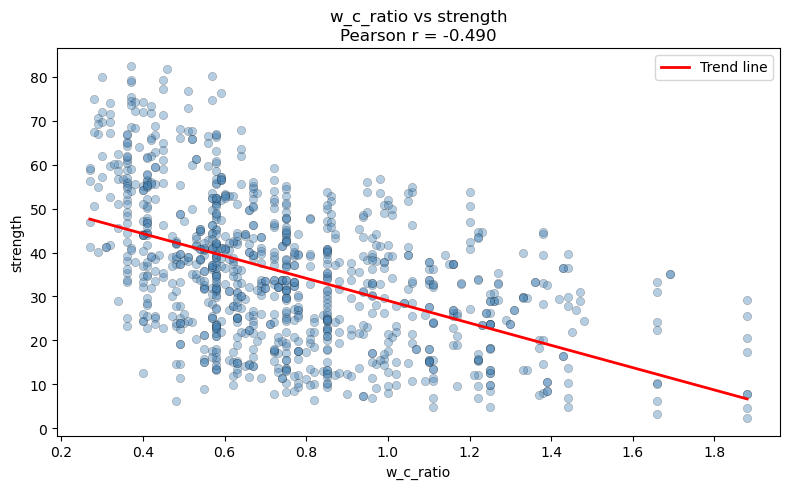

Pearson correlation: -0.4896


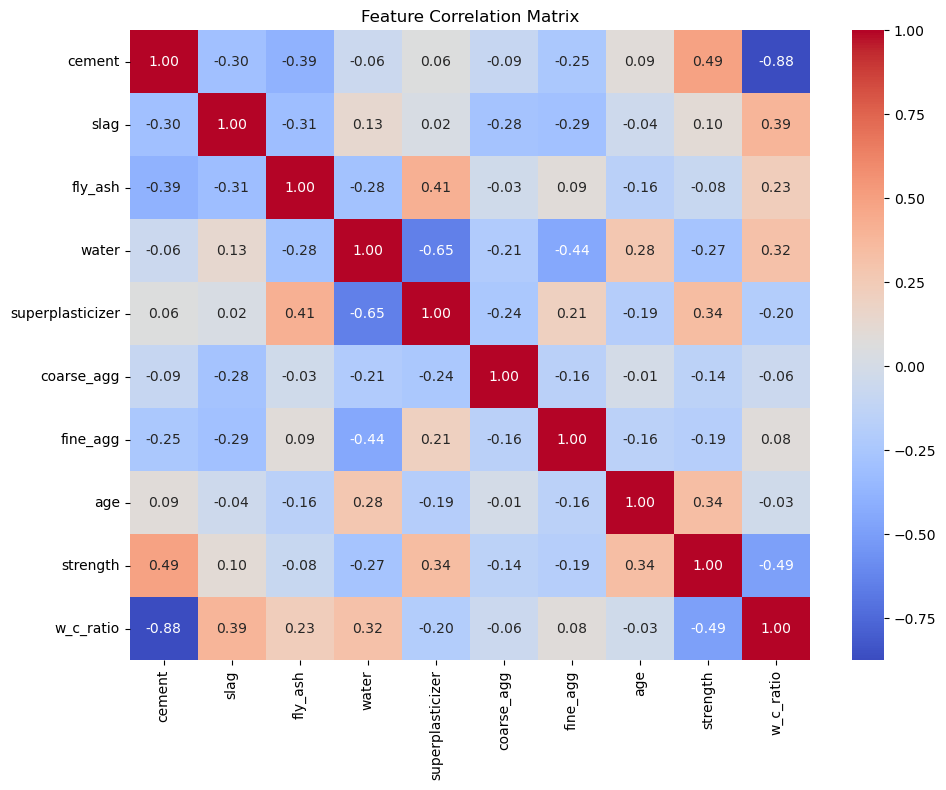

,cement,slag,fly_ash,water,superplasticizer,coarse_agg,fine_agg,age,strength,w_c_ratio
count,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000
mean,278.629055,72.043134,55.535075,182.074378,6.031647,974.376468,772.686617,45.856716,35.250273,0.756308
std,104.345003,86.170555,64.207448,21.340740,5.919559,77.579534,80.339851,63.734692,16.284808,0.313458
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808,0.270000
25%,190.680000,0.000000,0.000000,166.610000,0.000000,932.000000,724.300000,7.000000,23.523542,0.550000
50%,265.000000,20.000000,0.000000,185.700000,6.100000,968.000000,780.000000,28.000000,33.798114,0.690000
75%,349.000000,142.500000,118.270000,192.940000,10.000000,1031.000000,822.200000,56.000000,44.868340,0.940000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225,1.880000


In [ ]:
df["w_c_ratio"] = round(df["water"] / df["cement"] , 2)

plot_feature_vs_strength(df, "w_c_ratio", "strength") 
plot_correlation_matrix(df)
df.describe()

- Water to Binder Ratio


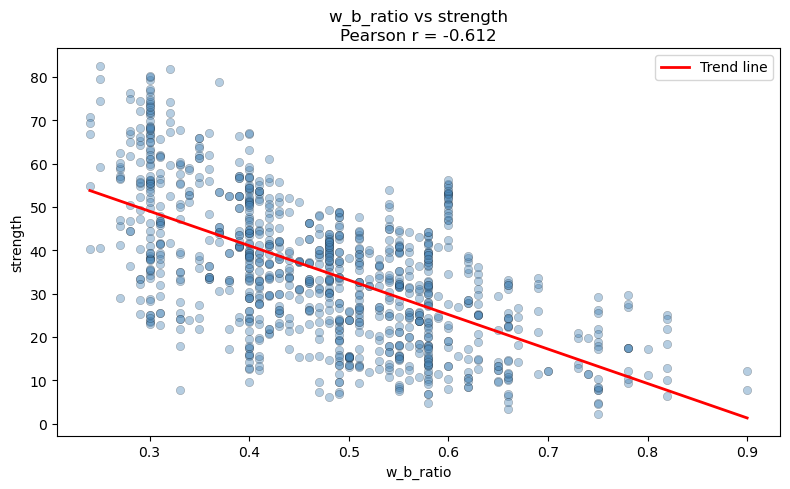

Pearson correlation: -0.6116


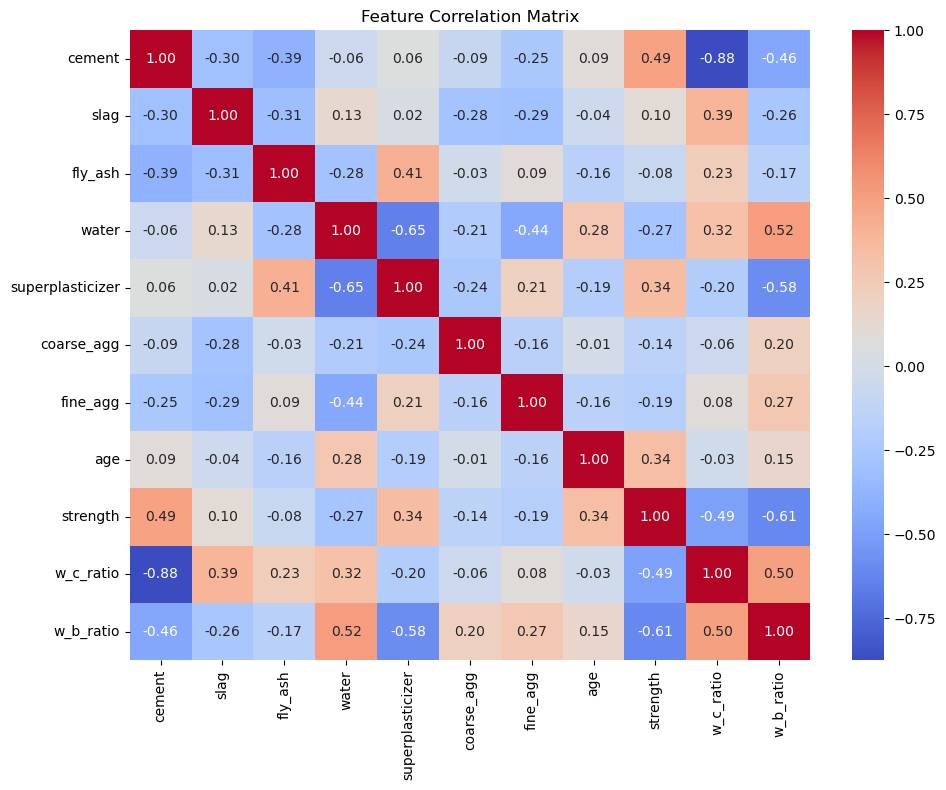

,cement,slag,fly_ash,water,superplasticizer,coarse_agg,fine_agg,age,strength,w_c_ratio,w_b_ratio
count,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000
mean,278.629055,72.043134,55.535075,182.074378,6.031647,974.376468,772.686617,45.856716,35.250273,0.756308,0.473114
std,104.345003,86.170555,64.207448,21.340740,5.919559,77.579534,80.339851,63.734692,16.284808,0.313458,0.125343
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808,0.270000,0.240000
25%,190.680000,0.000000,0.000000,166.610000,0.000000,932.000000,724.300000,7.000000,23.523542,0.550000,0.390000
50%,265.000000,20.000000,0.000000,185.700000,6.100000,968.000000,780.000000,28.000000,33.798114,0.690000,0.480000
75%,349.000000,142.500000,118.270000,192.940000,10.000000,1031.000000,822.200000,56.000000,44.868340,0.940000,0.560000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225,1.880000,0.900000


In [ ]:
df["w_b_ratio"] = round(df["water"] / (df["cement"] + df["slag"] + df["fly_ash"]),2)

plot_feature_vs_strength(df, "w_b_ratio", "strength")
plot_correlation_matrix(df)
df.describe()


- Cement to inert Matrix

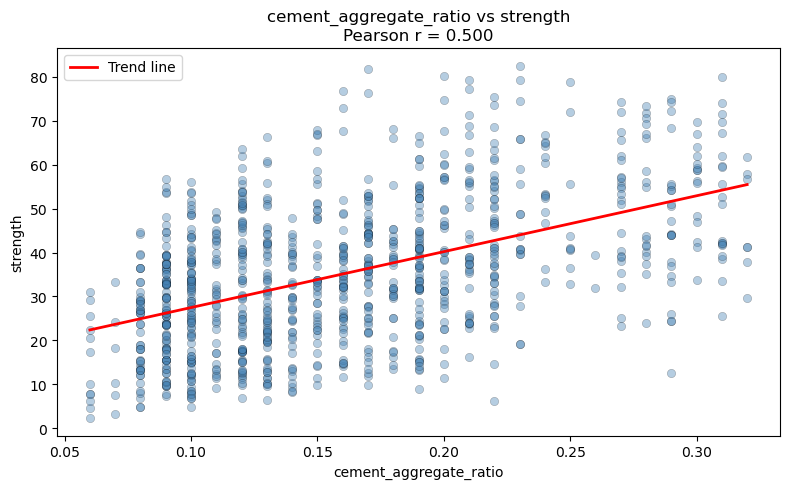

Pearson correlation: 0.4996


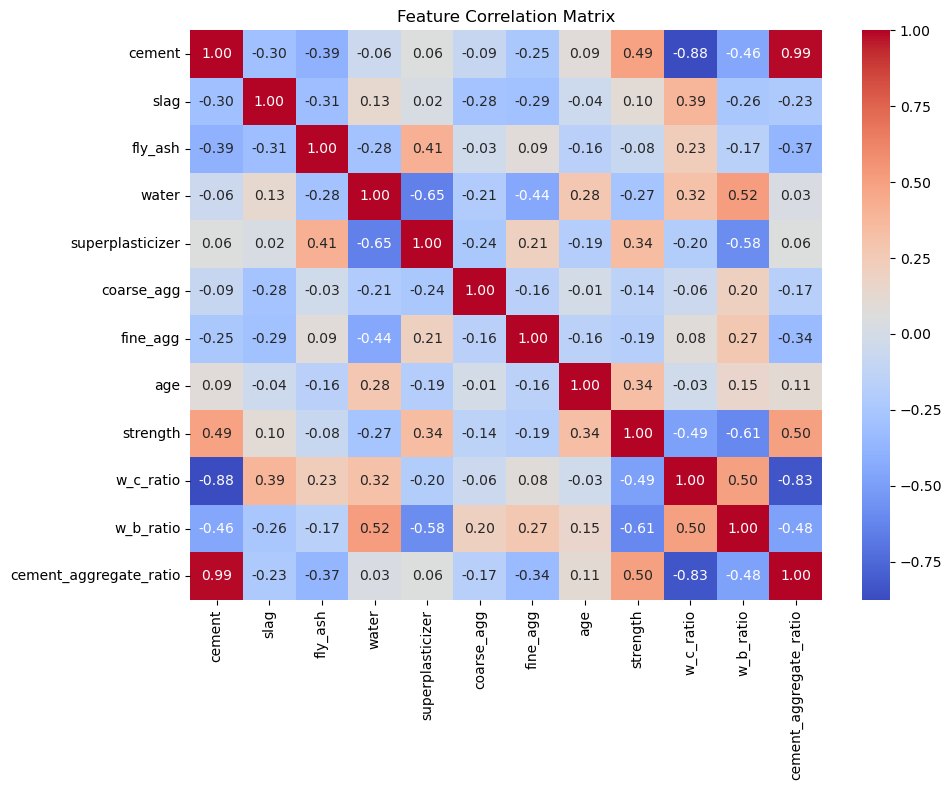

In [ ]:
df["cement_aggregate_ratio"] = round(df["cement"] / (df["coarse_agg"] + df["fine_agg"]),2)  
plot_feature_vs_strength(df, "cement_aggregate_ratio", "strength") 
plot_correlation_matrix(df)



In [ ]:
#to use cement-inert matrix alone - uncomment
#df.drop(columns=['cement', 'coarse_agg', 'fine_agg','water'], inplace=True)

#to use water-binder ratio alone - uncomment
#df.drop(columns=['water', 'cement','slag','fly_ash'], inplace=True)

#to use water cement ratio alone - uncomment
#df.drop(columns=['water', 'cement'], inplace=True)

#to use all engineered features - uncomment
df.drop(columns=['water', 'cement','slag','fly_ash','coarse_agg', 'fine_agg'], inplace=True)
df.to_csv("../Datasets/processed/uci_concrete_dataset/engineered_features.csv", index=False)